# Exploratory analysis — Daphnet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rokhaya8/fall-detection-lstm/blob/main/notebooks/00_eda_daphnet.ipynb)

Part of [fall-detection-lstm](https://github.com/Rokhaya8/fall-detection-lstm). Paths are set by `BASE_DIR` in the first code cell — adapt it to your Google Drive.

# 1. Configuration & Chargement des Données (Daphnet)
Initialisation de l'environnement, configuration du style graphique et définition des chemins vers le dataset Daphnet (détection du *Freezing of Gait* chez les patients parkinsoniens).

In [6]:
import warnings
warnings.filterwarnings('ignore')

# Core
import os
import glob
import zipfile
import numpy as np
import pandas as pd
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion Drive (à désactiver si exécution locale)
from google.colab import drive
drive.mount('/content/drive')

# ── Dossier du projet dans Google Drive (à adapter si besoin) ──
import os
BASE_DIR = '/content/drive/MyDrive/Projet_Parkinson'
os.makedirs(f'{BASE_DIR}/Figures', exist_ok=True)


# ── Configuration Minimaliste ───────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  '#FFFFFF',
    'axes.facecolor':    '#FFFFFF',
    'axes.edgecolor':    '#E0E0E0',
    'axes.labelcolor':   '#333333',
    'axes.titlecolor':   '#111111',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'grid.color':        '#F0F0F0',
    'grid.linestyle':    '-',
    'grid.alpha':        0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Couleurs Métiers (Daphnet) ──────────────────────────────
FOG_COLOR   = '#8E44AD'   # Violet profond pour le Freezing (Anomalie)
NORM_COLOR  = '#2E86C1'   # Bleu acier pour la marche normale
PALETTE     = [NORM_COLOR, FOG_COLOR]
sns.set_palette(PALETTE)

# ── Chemins & Décompression ──────────────────────────────────
CHEMIN_BASE = BASE_DIR
CHEMIN_ZIP = f'{CHEMIN_BASE}/Datasets_bruts/Daphnet_dataset.zip'
CHEMIN_DAPHNET = '/content/data/Daphnet_dataset'
CHEMIN_PLOTS= f'{CHEMIN_BASE}/Figures'

os.makedirs(CHEMIN_PLOTS, exist_ok=True)

# Extraction automatique
if not os.path.exists(CHEMIN_DAPHNET):
    print("Extraction de l'archive Daphnet en cours...")
    with zipfile.ZipFile(CHEMIN_ZIP, 'r') as zip_ref:
        zip_ref.extractall(CHEMIN_DAPHNET)
    print("Décompression terminée !")
else:
    print("Les données Daphnet sont déjà décompressées.")

print("Environnement configuré pour l'analyse Daphnet.")

Extraction de l'archive Daphnet en cours...
Décompression terminée !
Environnement configuré pour l'analyse Daphnet.


# 2. Moteur de Lecture et Prétraitement Physique
Contrairement à SisFall, les données brutes de Daphnet sont exprimées en milli-g et annotées sur 3 classes (0: Ignore, 1: Normal, 2: Freezing).

In [8]:
# 2. MOTEUR DE LECTURE ET PRÉTRAITEMENT PHYSIQUE

def lire_et_preparer_daphnet(chemin):
    """
    Lit un fichier texte Daphnet, nettoie les classes et applique
    rigoureusement les conversions physiques dans le bon ordre.
    """
    noms_colonnes = ['Time', 'Ankle_X', 'Ankle_Y', 'Ankle_Z',
                     'Thigh_X', 'Thigh_Y', 'Thigh_Z',
                     'Trunk_X', 'Trunk_Y', 'Trunk_Z', 'Annotation']

    # Lecture du fichier (espaces comme séparateurs)
    df = pd.read_csv(chemin, sep='\s+', header=None, names=noms_colonnes)

    # 1. Filtrage des données non-expérimentales (Classe 0)
    df = df[df['Annotation'] != 0].copy()

    # Remappage des classes : 1 -> 0 (Marche Normale), 2 -> 1 (Freezing)
    df['Classe'] = df['Annotation'].map({1: 0, 2: 1})

    colonnes_capteurs = ['Ankle_X', 'Ankle_Y', 'Ankle_Z', 'Thigh_X', 'Thigh_Y', 'Thigh_Z']

    # 2. Conversion Unitaire (mg vers g) AVANT toute autre opération
    df[colonnes_capteurs] = df[colonnes_capteurs] / 1000.0

    # 3. Clipping physique (-16G à 16G) pour éviter les valeurs aberrantes
    df[colonnes_capteurs] = np.clip(df[colonnes_capteurs], -16.0, 16.0)

    return df[['Time'] + colonnes_capteurs + ['Classe']]

# RECHERCHE ET CHARGEMENT DYNAMIQUE

print("Scan approfondi de l'arborescence Daphnet en cours...")

tous_les_txt = []
# os.walk pénètre dans absolument tous les dossiers et sous-dossiers
for racine, dossiers, fichiers in os.walk(CHEMIN_DAPHNET):
    for fichier in fichiers:
        if fichier.lower().endswith('.txt'):
            tous_les_txt.append(os.path.join(racine, fichier))

print(f"-> {len(tous_les_txt)} fichiers '.txt' trouvés au total dans l'arborescence.")

# Filtrage intelligent : on garde tout sauf les fichiers de documentation connus
mots_a_exclure = ['readme', 'demographics', 'format', 'info']
fichiers_daphnet = [
    f for f in tous_les_txt
    if not any(mot in os.path.basename(f).lower() for mot in mots_a_exclure)
]

print(f"Fichiers expérimentaux Daphnet retenus : {len(fichiers_daphnet)}\n")

if len(fichiers_daphnet) > 0:
    print("Exemples de chemins détectés :")
    for f in fichiers_daphnet[:3]:
        print(f"  - {f}")

    # Crash test sur le premier fichier
    try:
        df_test = lire_et_preparer_daphnet(fichiers_daphnet[0])
        print(f"\nPipeline validé sur : {os.path.basename(fichiers_daphnet[0])}")
        print("Aperçu physique après conversion (valeurs en G) :")
        display(df_test.head(3))
    except Exception as e:
        print(f"\nErreur de lecture : {e}")
else:
    print("AUCUN FICHIER RETENU.")
    print(f"Vérifiez que le chemin CHEMIN_DAPHNET ({CHEMIN_DAPHNET}) est bien celui où se trouvent vos données.")
    # Aide au debug : affiche ce qu'il y a vraiment dans le dossier
    try:
        print("\nContenu direct du dossier :", os.listdir(CHEMIN_DAPHNET))
    except FileNotFoundError:
        print("Le dossier racine n'existe pas. Le Drive est-il bien monté ?")

Scan approfondi de l'arborescence Daphnet en cours...
-> 17 fichiers '.txt' trouvés au total dans l'arborescence.
Fichiers expérimentaux Daphnet retenus : 17

Exemples de chemins détectés :
  - /content/data/Daphnet_dataset/uci-daphnet-freezing-of-gait/original/dataset_fog_release/dataset/S02R01.txt
  - /content/data/Daphnet_dataset/uci-daphnet-freezing-of-gait/original/dataset_fog_release/dataset/S05R01.txt
  - /content/data/Daphnet_dataset/uci-daphnet-freezing-of-gait/original/dataset_fog_release/dataset/S03R02.txt

Pipeline validé sur : S02R01.txt
Aperçu physique après conversion (valeurs en G) :


,Time,Ankle_X,Ankle_Y,Ankle_Z,Thigh_X,Thigh_Y,Thigh_Z,Classe
42879,670000,-0.151,0.990,0.267,0.063,0.990,0.08,0
42880,670015,-0.151,1.000,0.277,0.063,0.981,0.08,0
42881,670031,-0.181,1.009,0.247,0.063,0.981,0.07,0


# 3. Analyse du Déséquilibre Clinique (Domain Shift)
Contrairement aux chutes (événements ponctuels), le *Freezing of Gait* (FoG) peut durer plusieurs secondes. L'objectif de cette section est de quantifier le volume de données exploitable pour l'entraînement d'un futur modèle.

Comptage des événements sur l'ensemble du dataset...


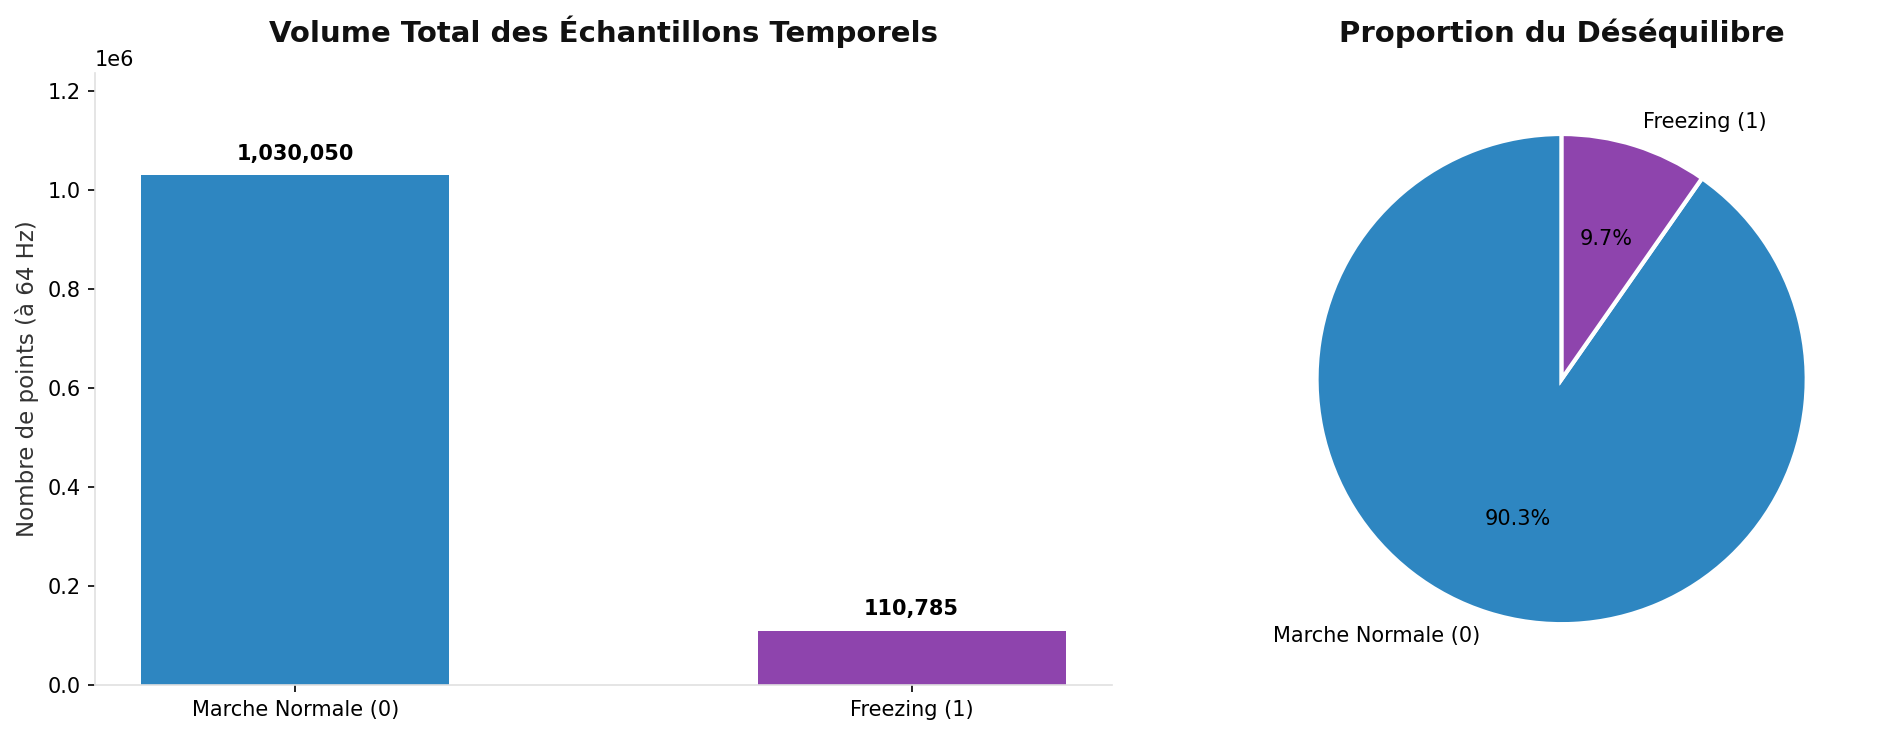

✓ Graphique sauvegardé : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/daphnet_distribution_classes.png


In [9]:
# CALCUL DE LA DISTRIBUTION GLOBALE
if len(fichiers_daphnet) > 0:
    print("Comptage des événements sur l'ensemble du dataset...")

    total_normal = 0
    total_fog = 0

    for f in fichiers_daphnet:
        df_temp = lire_et_preparer_daphnet(f)
        comptes = df_temp['Classe'].value_counts()
        total_normal += comptes.get(0, 0)
        total_fog += comptes.get(1, 0)

    # --- Visualisation ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels = ['Marche Normale (0)', 'Freezing (1)']
    valeurs = [total_normal, total_fog]

    # Diagramme en barres
    bars = axes[0].bar(labels, valeurs, color=PALETTE, width=0.5)
    axes[0].set_title('Volume Total des Échantillons Temporels', pad=15, fontweight='bold')
    axes[0].set_ylabel('Nombre de points (à 64 Hz)')

    for bar in bars:
        hauteur = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., hauteur + (sum(valeurs)*0.02),
                     f'{int(hauteur):,}', ha='center', va='bottom', fontweight='bold')
    axes[0].set_ylim(0, max(valeurs) * 1.2)

    # Diagramme circulaire (Proportion)
    axes[1].pie(valeurs, labels=labels, colors=PALETTE, autopct='%1.1f%%',
                startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Proportion du Déséquilibre', pad=15, fontweight='bold')

    plt.tight_layout()
    chemin_dist = f'{CHEMIN_PLOTS}/daphnet_distribution_classes.png'
    plt.savefig(chemin_dist, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✓ Graphique sauvegardé : {chemin_dist}")

# 4. Signatures Temporelles : Marche Fluide vs Freezing
Observation dynamique des signaux d'accélération (Cheville). Le Freezing se manifeste visuellement par des oscillations rapides de faible amplitude (tremblements des membres inférieurs) plutôt que par de grands déplacements.

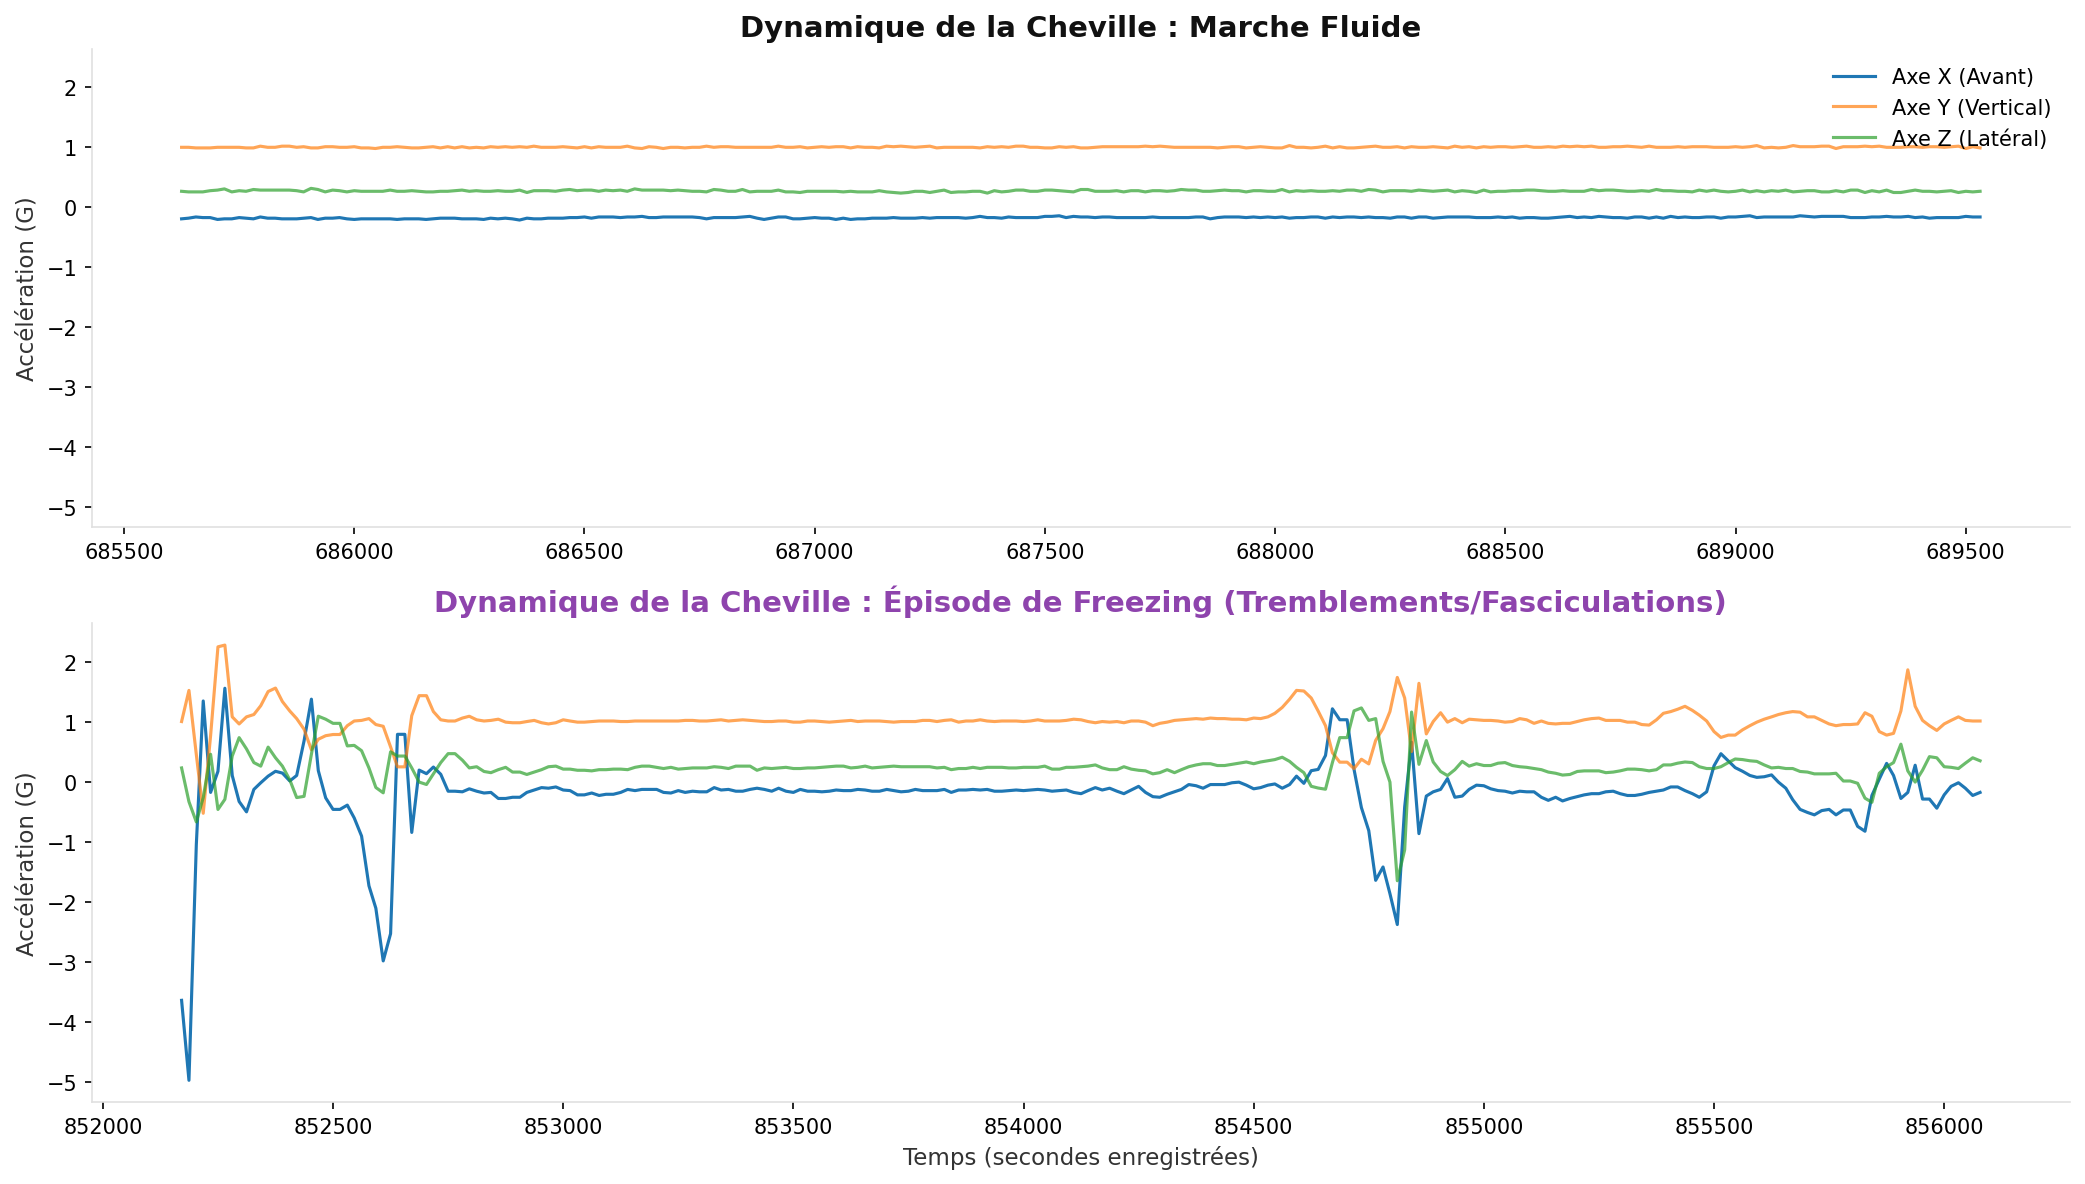

✓ Signatures temporelles sauvegardées : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/daphnet_signatures_temporelles.png


In [10]:
# EXTRACTION ET TRACÉ D'UN ÉPISODE DE FREEZING
if len(fichiers_daphnet) > 0:
    # Recherche du premier fichier contenant un épisode de Freezing
    df_cible = None
    for f in fichiers_daphnet:
        df_temp = lire_et_preparer_daphnet(f)
        if 1 in df_temp['Classe'].values:
            df_cible = df_temp
            break

    if df_cible is not None:
        # Fenêtre de 4 secondes (256 échantillons à 64Hz)
        idx_normal = df_cible[df_cible['Classe'] == 0].index[1000]
        idx_fog = df_cible[df_cible['Classe'] == 1].index[50] # Début de l'épisode

        fenetre_normale = df_cible.loc[idx_normal : idx_normal + 250]
        fenetre_fog = df_cible.loc[idx_fog : idx_fog + 250]

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False, sharey=True)

        # Axe 1 : Marche Normale
        axes[0].plot(fenetre_normale['Time'], fenetre_normale['Ankle_X'], label='Axe X (Avant)', color='#1f77b4')
        axes[0].plot(fenetre_normale['Time'], fenetre_normale['Ankle_Y'], label='Axe Y (Vertical)', color='#ff7f0e', alpha=0.7)
        axes[0].plot(fenetre_normale['Time'], fenetre_normale['Ankle_Z'], label='Axe Z (Latéral)', color='#2ca02c', alpha=0.7)
        axes[0].set_title("Dynamique de la Cheville : Marche Fluide", fontweight='bold')
        axes[0].set_ylabel("Accélération (G)")
        axes[0].legend(loc='upper right', frameon=False)

        # Axe 2 : Freezing
        axes[1].plot(fenetre_fog['Time'], fenetre_fog['Ankle_X'], color='#1f77b4')
        axes[1].plot(fenetre_fog['Time'], fenetre_fog['Ankle_Y'], color='#ff7f0e', alpha=0.7)
        axes[1].plot(fenetre_fog['Time'], fenetre_fog['Ankle_Z'], color='#2ca02c', alpha=0.7)
        axes[1].set_title("Dynamique de la Cheville : Épisode de Freezing (Tremblements/Fasciculations)", fontweight='bold', color=FOG_COLOR)
        axes[1].set_xlabel("Temps (secondes enregistrées)")
        axes[1].set_ylabel("Accélération (G)")

        plt.tight_layout()
        chemin_sig = f'{CHEMIN_PLOTS}/daphnet_signatures_temporelles.png'
        plt.savefig(chemin_sig, bbox_inches='tight', dpi=300)
        plt.show()
        print(f"✓ Signatures temporelles sauvegardées : {chemin_sig}")

# 5. Preuve Statistique de Séparabilité (Variance de l'Énergie)
Contrairement aux chutes de SisFall (où l'on cherchait un pic G massif), le Freezing est une agitation. Nous calculons la variance de la Magnitude du Vecteur (SVM) sur des fenêtres de 1 seconde et appliquons un test de Mann-Whitney.

Test de Mann-Whitney (Variance SVM) : p-value = 4.04e-10
Différence significative validée : L'énergie oscillatoire sépare les classes.


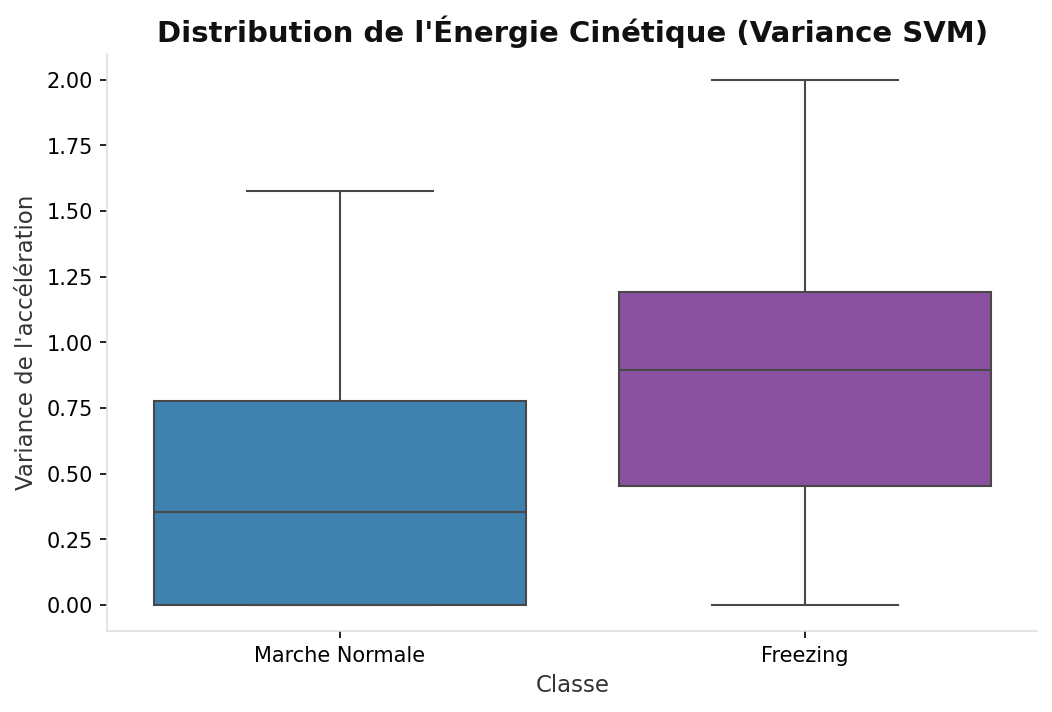

Boxplot sauvegardé : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/daphnet_variance_boxplot.png


In [11]:
# EXTRACTION DE LA VARIANCE ET TEST DE MANN-WHITNEY
from scipy.stats import mannwhitneyu

if df_cible is not None:
    taille_fenetre = 64 # 1 seconde de données à 64 Hz
    variances_norm = []
    variances_fog = []

    # Création d'indices pour l'échantillonnage de fenêtres
    idx_normaux = df_cible[df_cible['Classe'] == 0].index[::taille_fenetre][:-1]
    idx_fogs = df_cible[df_cible['Classe'] == 1].index[::taille_fenetre][:-1]

    # Calcul de la variance sur la cheville
    for idx in idx_normaux[:400]:
        fenetre = df_cible.loc[idx:idx+taille_fenetre]
        svm = np.sqrt(fenetre['Ankle_X']**2 + fenetre['Ankle_Y']**2 + fenetre['Ankle_Z']**2)
        variances_norm.append(svm.var())

    for idx in idx_fogs[:400]:
        fenetre = df_cible.loc[idx:idx+taille_fenetre]
        svm = np.sqrt(fenetre['Ankle_X']**2 + fenetre['Ankle_Y']**2 + fenetre['Ankle_Z']**2)
        variances_fog.append(svm.var())

    # Preuve Statistique
    stat, p = mannwhitneyu(variances_fog, variances_norm, alternative='two-sided')
    print(f"Test de Mann-Whitney (Variance SVM) : p-value = {p:.2e}")
    if p < 0.05:
        print("Différence significative validée : L'énergie oscillatoire sépare les classes.")

    # Boxplot
    plt.figure(figsize=(8, 5))
    df_box = pd.DataFrame({
        'Variance': variances_norm + variances_fog,
        'Classe': ['Marche Normale']*len(variances_norm) + ['Freezing']*len(variances_fog)
    })

    sns.boxplot(data=df_box, x='Classe', y='Variance', palette=PALETTE, showfliers=False)
    plt.title("Distribution de l'Énergie Cinétique (Variance SVM)", fontweight='bold')
    plt.ylabel("Variance de l'accélération")

    chemin_box = f'{CHEMIN_PLOTS}/daphnet_variance_boxplot.png'
    plt.savefig(chemin_box, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Boxplot sauvegardé : {chemin_box}")

# 6. Analyse Fréquentielle (Transformée de Fourier Rapide - FFT)
En biomécanique, la signature d'un patient parkinsonien est spectrale. La marche normale se situe dans la bande locomotrice (0.5 - 3 Hz), tandis que le Freezing génère un pic dans la bande de "tremblement" (3 - 8 Hz).

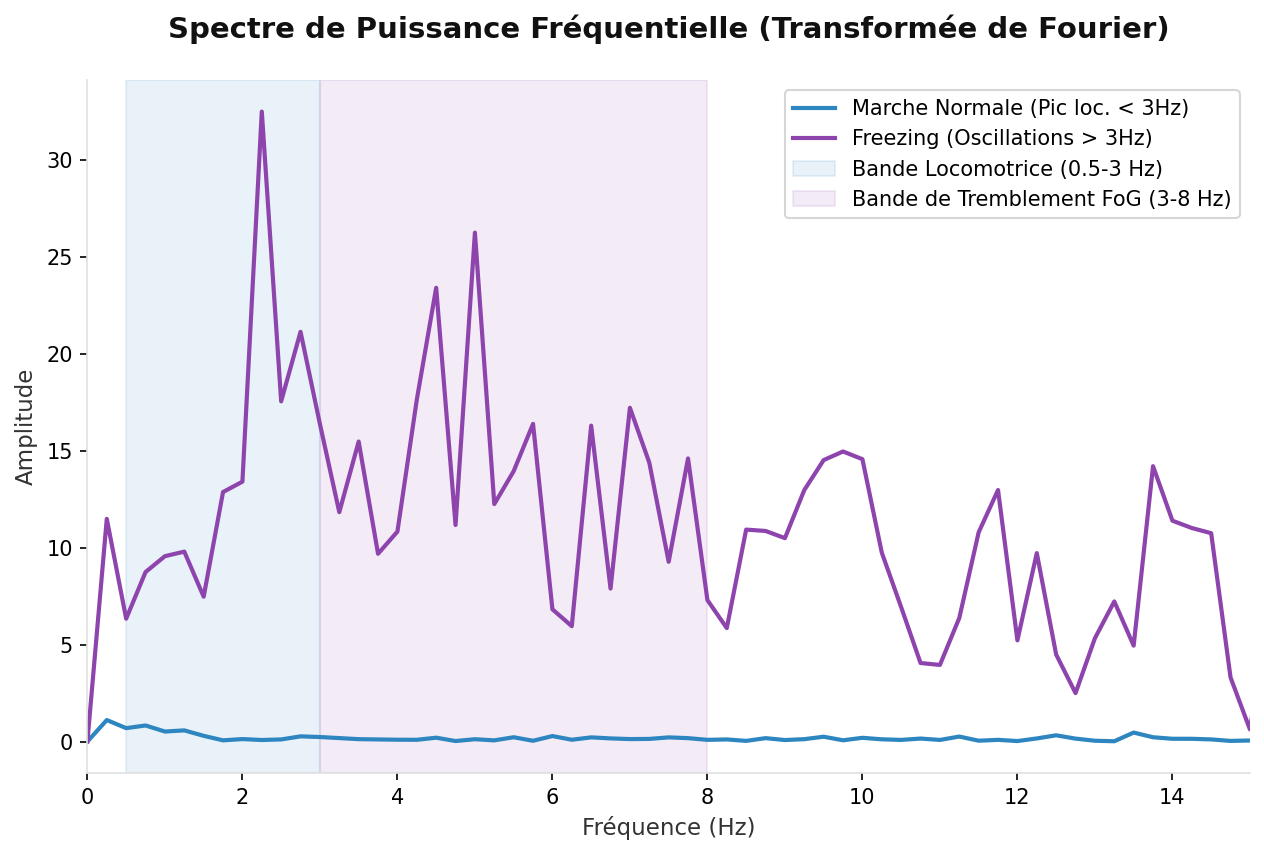

✓ Spectre fréquentiel sauvegardé : /content/drive/MyDrive/Projet_Parkinson/Notebooks/Plots/daphnet_spectre_fft.png


In [13]:
# ANALYSE SPECTRALE (FFT) POUR PROUVER LE CHANGEMENT DE BANDE
if df_cible is not None:
    fs = 64 # Fréquence d'échantillonnage de Daphnet
    N = 256 # Taille optimale pour l'algorithme FFT (puissance de 2)

    # On isole l'axe d'accélération X (Avant) et on centre le signal sur 0
    signal_normal = fenetre_normale['Ankle_X'].values - np.mean(fenetre_normale['Ankle_X'].values)
    signal_fog = fenetre_fog['Ankle_X'].values - np.mean(fenetre_fog['Ankle_X'].values)

    # Calcul de la Transformée de Fourier Rapide (avec n=N pour forcer l'alignement des axes)
    fft_normal = np.abs(np.fft.rfft(signal_normal, n=N))
    fft_fog = np.abs(np.fft.rfft(signal_fog, n=N))
    freqs = np.fft.rfftfreq(N, d=1/fs)

    # Tracé des Spectres
    plt.figure(figsize=(10, 6))
    plt.plot(freqs, fft_normal, label='Marche Normale (Pic loc. < 3Hz)', color=NORM_COLOR, linewidth=2)
    plt.plot(freqs, fft_fog, label='Freezing (Oscillations > 3Hz)', color=FOG_COLOR, linewidth=2)

    # Ajout des zones cliniques (Bandes de fréquences reconnues dans la littérature)
    plt.axvspan(0.5, 3.0, color=NORM_COLOR, alpha=0.1, label='Bande Locomotrice (0.5-3 Hz)')
    plt.axvspan(3.0, 8.0, color=FOG_COLOR, alpha=0.1, label='Bande de Tremblement FoG (3-8 Hz)')

    plt.title("Spectre de Puissance Fréquentielle (Transformée de Fourier)", pad=20, fontweight='bold')
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 15) # On coupe à 15Hz car le mouvement humain dépasse rarement cette fréquence
    plt.legend(frameon=True)

    chemin_fft = f'{CHEMIN_PLOTS}/daphnet_spectre_fft.png'
    plt.savefig(chemin_fft, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✓ Spectre fréquentiel sauvegardé : {chemin_fft}")